In [ ]:
# 1. Importação de bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import re

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vishakhdapat/imdb-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-movie-reviews


Dimensões: (50000, 2)
Colunas: Index(['review', 'sentiment'], dtype='object')
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


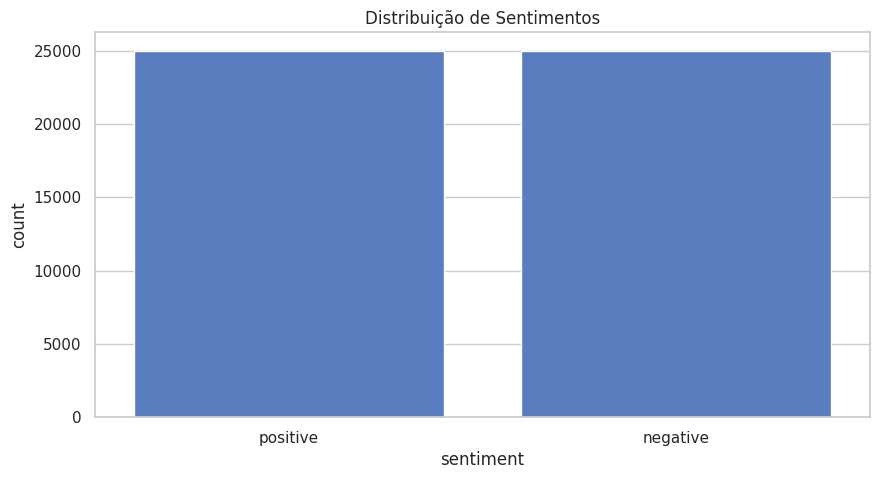

In [ ]:
# Configurações de visualização
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)


# O arquivo principal é 'IMDB Dataset.csv'
csv_file = path + "/IMDB Dataset.csv"

# Carregar o CSV
df = pd.read_csv(csv_file)

# Visualizar primeiras linhas
df.head()

# 3. Estrutura inicial da base
print("Dimensões:", df.shape)
print("Colunas:", df.columns)

# Distribuição das classes
print(df['sentiment'].value_counts())

sns.countplot(data=df, x='sentiment')
plt.title("Distribuição de Sentimentos")
plt.show()

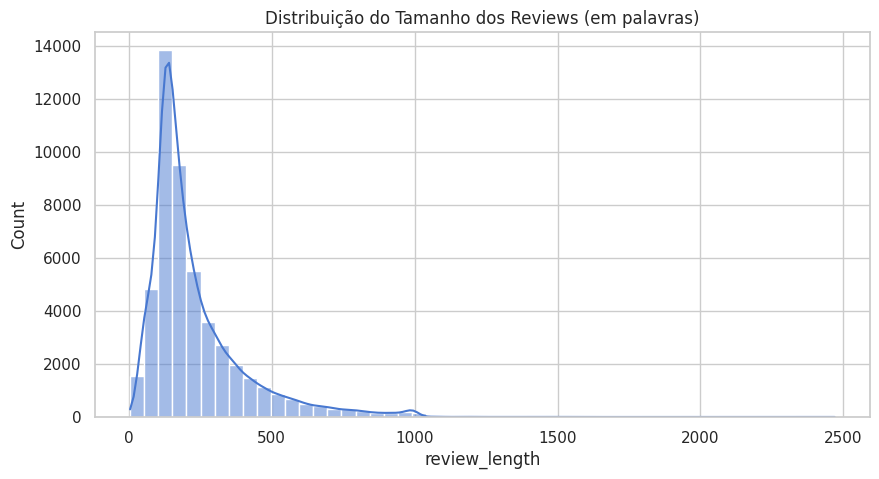

Média de palavras por review: 231.15694
Máximo de palavras em um review: 2470


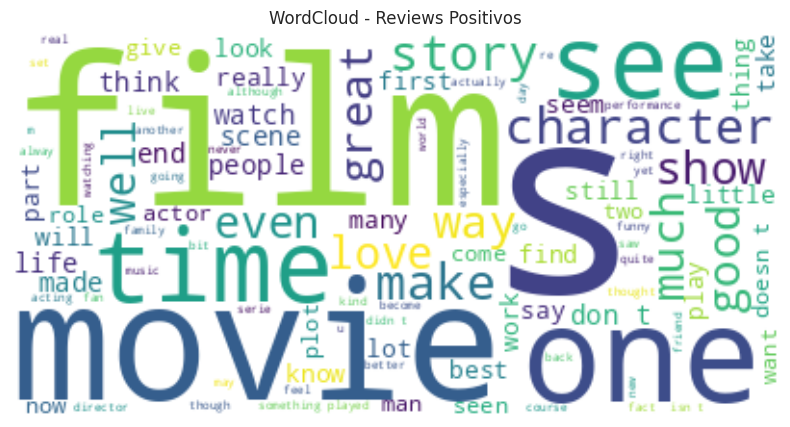

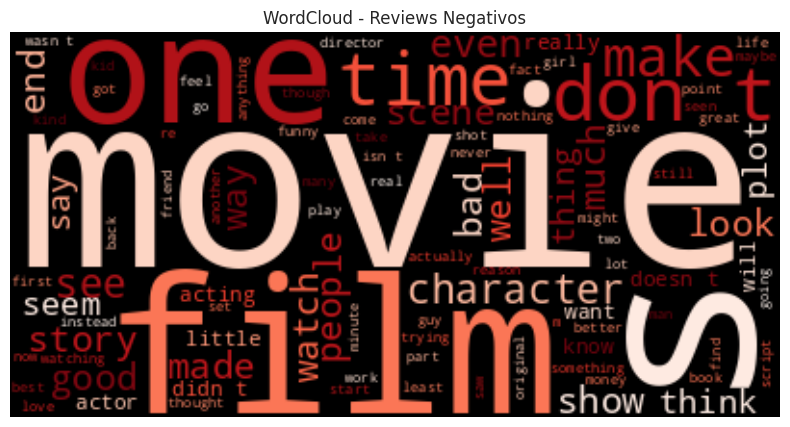

In [ ]:
# 4. Tamanho dos reviews

df['review_length'] = df['review'].apply(lambda x: len(x.split()))

sns.histplot(df['review_length'], bins=50, kde=True)
plt.title("Distribuição do Tamanho dos Reviews (em palavras)")
plt.show()

print("Média de palavras por review:", np.mean(df['review_length']))
print("Máximo de palavras em um review:", np.max(df['review_length']))

# 5. Limpeza básica do texto (para análise de palavras)

def clean_text(text):
    text = re.sub(r"<.*?>", " ", text)  # remove tags HTML
    text = re.sub(r"[^a-zA-Z]", " ", text)  # mantém apenas letras
    text = text.lower()
    return text

df['clean_review'] = df['review'].apply(clean_text)


# 6. WordCloud - Reviews Positivos

positive_text = " ".join(df[df['sentiment']=='positive']['clean_review'].values)

wc_pos = WordCloud(stopwords=STOPWORDS, background_color="white", max_words=100).generate(positive_text)

plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Reviews Positivos")
plt.show()

# 7. WordCloud - Reviews Negativos
negative_text = " ".join(df[df['sentiment']=='negative']['clean_review'].values)

wc_neg = WordCloud(stopwords=STOPWORDS, background_color="black", colormap="Reds", max_words=100).generate(negative_text)

plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Reviews Negativos")
plt.show()


In [ ]:

# 8. Frequência de palavras (exemplo com positivos)

from collections import Counter

pos_words = positive_text.split()
neg_words = negative_text.split()

pos_counts = Counter(pos_words)
neg_counts = Counter(neg_words)

print("Top 20 palavras mais comuns (positivas):")
print(pos_counts.most_common(20))

print("\nTop 20 palavras mais comuns (negativas):")
print(neg_counts.most_common(20))

Top 20 palavras mais comuns (positivas):
[('the', 341289), ('and', 176634), ('a', 164375), ('of', 152109), ('to', 131322), ('is', 111834), ('in', 99254), ('it', 95135), ('i', 82004), ('this', 69648), ('that', 69595), ('s', 67010), ('as', 51116), ('with', 45718), ('for', 44236), ('was', 43339), ('film', 42111), ('but', 40730), ('movie', 37854), ('on', 33752)]

Top 20 palavras mais comuns (negativas):
[('the', 326720), ('a', 158685), ('and', 147805), ('of', 137306), ('to', 136801), ('is', 99258), ('it', 95727), ('i', 93623), ('in', 87533), ('this', 81353), ('that', 74286), ('s', 62781), ('was', 52267), ('movie', 50118), ('for', 43235), ('but', 42823), ('with', 41650), ('t', 40922), ('as', 40648), ('film', 37597)]


In [ ]:
# 3. Limpeza e pré-processamento rápido do texto

stop_words = set(stopwords.words('english'))

def preprocess_text_fast(text):
    # Remove HTML
    text = re.sub(r"<.*?>", " ", text)
    # Remove pontuação e números
    text = re.sub(r"[^a-zA-Z]", " ", text)
    # Minúsculas
    text = text.lower()
    # Tokenização simples
    tokens = text.split()
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Aplicar pré-processamento rápido
df['clean_review'] = df['review'].apply(preprocess_text_fast)


# 4. Vetorização TF-IDF

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(df['clean_review'])
y = df['sentiment'].map({'positive': 1, 'negative': 0})  # converte labels para 0 e 1

# 5. Divisão em treino, validação e teste

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print("Shape Treino:", X_train.shape)
print("Shape Validação:", X_val.shape)
print("Shape Teste:", X_test.shape)


Shape Treino: (34998, 5000)
Shape Validação: (7502, 5000)
Shape Teste: (7500, 5000)
